## 1. INSTALL DEPENDANCIES
  requests is a python module that allows us to call api's easly without woring about low level details
  

IN Order to work with this notebook 
1 - Go to https://developer.spotify.com/ 
2- Create an account 
3- Create an application

In [1]:
!pip install -r requirements.txt

In [68]:
import os
import requests
import json
import pandas as pd
from dotenv import load_dotenv

pd.set_option('display.max_columns', None)      # Show all columns
pd.set_option('display.expand_frame_repr', False)  # Don't wrap to a new line
pd.set_option('display.max_colwidth', 150)

In [29]:
# load environment variables

load_dotenv(override=True)
SPOTIFY_OAUTH_ENDPOINT=os.getenv('SPOTIFY_OAUTH_ENDPOINT')
SPOTIFY_API_ENDPOINT = os.getenv('SPOTIFY_API_ENDPOINT')
SPOTIFY_CLIENT_ID = os.getenv('SPOTIFY_CLIENT_ID')
SPOTIFY_CLIENT_SECRET = os.getenv('SPOTIFY_CLIENT_SECRET')



In [34]:
def get_token(endpoint, clientId, clientSecret):
    grant_type = 'client_credentials'
    # parameters of the API call
    body_params = {
        'client_id': clientId,
        'client_secret': clientSecret,
        'grant_type' : grant_type
        }

    url=f'{endpoint}/api/token' # formating the full endpoint
    try:
        response = requests.post(url, data=body_params) # making request to spotify to get a token
        token_raw = json.loads(response.text)
        token = token_raw["access_token"] # extracting access_token from api result
        return token
    except Exception as ex :
        print(f"Got an authentification error {ex}")

In [72]:
def miliseconds_to_minutes(millis):
    millis = int(millis)
    seconds=(millis/1000)%60
    seconds = int(seconds)
    minutes=(millis/(1000*60))%60
    minutes = int(minutes)
    return  f"{minutes} m {seconds} s"


In [ ]:

def find_tracks_by_artiste(artist):

    # Get access token
    access_token = get_token(SPOTIFY_OAUTH_ENDPOINT, SPOTIFY_CLIENT_ID, SPOTIFY_CLIENT_SECRET)

    # API CALL
    search_response = requests.get(
        url = f'{SPOTIFY_API_ENDPOINT}/v1/search',
        headers={
            'Authorization': f'Bearer {access_token}'
        },
        params={
            'q': f'artist:{artist}',
            'type': 'track',
            'market': 'MR',
        }
    )
    # Parse result
    tracks = search_response.json().get('tracks', {}).get('items', [])
    return tracks




def get_most_popular_songs(tracks):

    songs = []
    for  track in tracks:
        artists = ', '.join(artist['name'] for artist in track.get('artists', []))
        spotify_url = track.get('external_urls', {}).get('spotify')
        full_name = f"{track.get('name')} by {artists}"
        
        extracted_data = {
            "popularity": track.get('popularity'),
            "spotify_url": str(spotify_url),
            "full_name": full_name,
            "release_date": track.get('album', {}).get('release_date'),
            "duration_m": miliseconds_to_minutes(track.get('duration_ms'))

            }
        songs.append(extracted_data)

    songs_df = pd.DataFrame(songs)
    songs_df = songs_df.sort_values(by='popularity', ascending=False)
    return songs_df.head(10)

In [111]:
import matplotlib.pyplot as plt


def display_songs_chart(songs_df):
    fig, ax = plt.subplots()
    fig.autofmt_xdate(rotation=45)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

    songs_df = songs_df.head(10)
    ax.bar(songs_df["full_name"], songs_df["popularity"], color=colors)

    ax.set_ylabel('popularity %')
    ax.set_title('Song Bame')
    ax.legend(title='Spotify Songs analysis')

    plt.show()


In [105]:
def save_data_to_json_fil(filename, data):
    with open (filename, 'w') as f:
        f.write(json.dumps(data))

<Response [200]>


/var/folders/k9/f1zb4yq168n5ynbtdl7lfvrm0000gn/T/ipykernel_69874/3833940021.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Spotify Songs analysis')


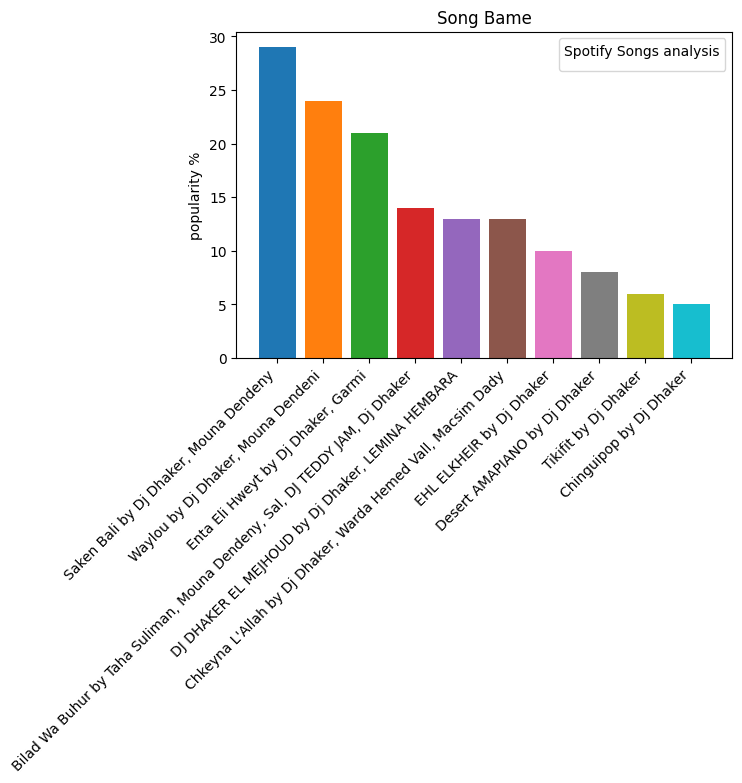

   popularity                                            spotify_url                                                                    full_name release_date duration_m
0          29  https://open.spotify.com/track/30pn5i0OugSFjGilb8cmX6                                       Saken Bali by Dj Dhaker, Mouna Dendeny   2019-12-31   3 m 27 s
1          24  https://open.spotify.com/track/75u0wud7Olc0EvCkK1hCWx                                           Waylou by Dj Dhaker, Mouna Dendeni   2020-02-26   3 m 34 s
3          21  https://open.spotify.com/track/5stEpLG1ZgM1NgBFdLtC1h                                           Enta Eli Hweyt by Dj Dhaker, Garmi   2020-09-13   3 m 45 s
5          14  https://open.spotify.com/track/2uIkoINTFtPGegqqBJKfXV  Bilad Wa Buhur by Taha Suliman, Mouna Dendeny, Sal, DJ TEDDY JAM, Dj Dhaker   2021-07-07   4 m 10 s
2          13  https://open.spotify.com/track/2TSXWSKSozRDSAwOVXPxeS                            DJ DHAKER EL MEJHOUD by Dj Dhaker, LEMINA HEMBARA   20

In [114]:

#     # Dj Dhaker
artist = "Dj Dhaker"
songs = find_tracks_by_artiste(artist)
save_data_to_json_fil('dj_dhaker.json', songs)


# get most popular songs 

result = get_most_popular_songs(songs)
display_songs_chart(result)
print(result)